In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_state = 42

# Load Ames dataset
data_path = '/mnt/c/Users/futha/source/python-projects/pyml-book/datasets/AmesHousing.txt'
df = pd.read_csv(data_path, sep='\t',)

# Problem statement
The final goal for this dataset is to accurately predict the price of a house in the city of Ames, Iowa, given several number of features taken from previous house sales in that city.

# Initial Inspection

## Dataset info

In [2]:
# Shape of the dataset
df.shape

(2930, 82)

The AMES dataset has 2930 examples each with 82 features. One of them is the target variable `SalePrice`.

In [3]:
# View the first 10 examples
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [4]:
# Print a concise summary of the dataset
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

We have several kinds of both categorical (nominal and ordinal) and numeric features.

# Data Quality Checks

## Unique values

In [5]:
# Number of unique values
df.nunique()

Order             2930
PID               2930
MS SubClass         16
MS Zoning            7
Lot Frontage       128
                  ... 
Mo Sold             12
Yr Sold              5
Sale Type           10
Sale Condition       6
SalePrice         1032
Length: 82, dtype: int64

The `Order` and `PID` features are just identifiers for the single sale and we can safely remove them.

In [6]:
df = df.drop(columns=['Order', 'PID'])

## Null-Values

In [7]:
# Percentage of null values
na_cols = df.isna().mean().sort_values(ascending=False)
na_cols

Pool QC           0.995563
Misc Feature      0.963823
Alley             0.932423
Fence             0.804778
Mas Vnr Type      0.605802
                    ...   
Mo Sold           0.000000
Yr Sold           0.000000
Sale Type         0.000000
Sale Condition    0.000000
SalePrice         0.000000
Length: 80, dtype: float64

Features with a very high percentage of null values are better deleted than imputed. For this example, we will remove all features having more than one fifth of the total examples as invalid for that given feature (i.e. `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Mas Vnr Type`, `Fireplace Qu`)

In [8]:
high_na_cols = na_cols[na_cols > 0.2].index
df = df.drop(columns=high_na_cols)

## Rename features
Rename features to remove whitespaces from feature names

In [9]:
from utils import name_map
df = df.rename(columns=name_map)

## Validate values
Check if categoricals have expected values and if numerical features are inside allowed bounds.

In [10]:
from utils import validate_numerical_features, validate_categorical_features
from utils import numerical_invariants, categorical_invariants

num_violations, cat_violations = \
    validate_numerical_features(df, numerical_invariants), validate_categorical_features(df, categorical_invariants)

print('Numerical features violations:\n')
for col, info in num_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")
print('Categorical features violations:\n')
for col, info in cat_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")


Numerical features violations:

Categorical features violations:

	MSZoning: 29 violations - ['C (all)', 'I (all)', 'A (agr)']
	BldgType: 272 violations - ['Twnhs', 'Duplex', '2fmCon']
	Exterior1st: 476 violations - ['Wd Sdng', 'WdShing']
	Exterior2nd: 626 violations - ['Wd Sdng', 'CmentBd', 'Wd Shng', 'Brk Cmn']
	SaleType: 2536 violations - ['WD ']


Numerical features are ok, while categoricals have some values with some typos that we will fix.

In [11]:
from utils import exterior1st_correct_values, exterior2d_correct_values
from utils import mszoning_correct_values, bldgtype_correct_values, saletype_correct_values

df = df.replace({
    'MSZoning': mszoning_correct_values,
    'BldgType': bldgtype_correct_values,
    'Exterior1st': exterior1st_correct_values,
    'Exterior2nd': exterior2d_correct_values,
    'SaleType': saletype_correct_values
})

num_violations, cat_violations = \
    validate_numerical_features(df, numerical_invariants), validate_categorical_features(df, categorical_invariants)

print('Numerical features violations:\n')
for col, info in num_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")
print('Categorical features violations:\n')
for col, info in cat_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")

Numerical features violations:

Categorical features violations:



## Impute missing values
For this example, we will simply replace the null values for numeric features with the median of that feature, while for categoricals we will use the most frequent value for that feature.

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_cols = list(df.select_dtypes(include='number').columns)
cat_cols = list(df.select_dtypes(exclude='number').columns)

imputer  = ColumnTransformer([
    ('num_imputer', SimpleImputer(strategy='median'), num_cols),
    ('cat_imputer', SimpleImputer(strategy='most_frequent'), cat_cols)], 
    verbose_feature_names_out=False)

imputer.set_output(transform='pandas')
df = imputer.fit_transform(df)
df.sample(10)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemod/Add,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
2368,160.0,21.0,1680.0,6.0,5.0,1971.0,1971.0,236.0,0.0,0.0,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,N,WD,Abnorml
773,85.0,68.0,8014.0,6.0,5.0,1978.0,1978.0,23.0,456.0,0.0,...,SBrkr,TA,Typ,Basment,Fin,TA,TA,Y,WD,Normal
2613,20.0,60.0,7332.0,6.0,6.0,1959.0,1959.0,207.0,414.0,0.0,...,SBrkr,Gd,Typ,Attchd,Unf,TA,TA,Y,WD,Abnorml
2159,20.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,0.0,699.0,0.0,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1303,20.0,50.0,6000.0,5.0,6.0,1957.0,1957.0,0.0,308.0,0.0,...,FuseA,TA,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
1184,60.0,68.0,7500.0,7.0,5.0,2002.0,2002.0,0.0,0.0,0.0,...,SBrkr,TA,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1401,20.0,73.0,39104.0,7.0,7.0,1954.0,2005.0,0.0,226.0,1063.0,...,SBrkr,TA,Mod,Attchd,Unf,TA,TA,Y,WD,Normal
1012,20.0,53.0,15401.0,9.0,5.0,2004.0,2004.0,296.0,1337.0,0.0,...,SBrkr,Ex,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
1688,20.0,93.0,12085.0,8.0,5.0,2007.0,2007.0,328.0,1004.0,0.0,...,SBrkr,Ex,Typ,Attchd,RFn,TA,TA,Y,New,Partial
303,50.0,50.0,9140.0,6.0,5.0,1921.0,1975.0,0.0,308.0,0.0,...,SBrkr,TA,Typ,Detchd,Unf,TA,TA,Y,COD,Normal


## Correct dtypes
Assign the most appropriate dtype to each feature, as some (`MS SubClass`, `OverallQual`, `OverallCond`) have numeric integer values but are in-fact categorical. 

In [13]:
from pandas.api.types import CategoricalDtype
from utils import numerical_invariants, categorical_invariants, ordered_categories
from utils import int_feat, float_feat
for col in df.columns:
    if col in numerical_invariants.keys():
        df[col] = df[col].astype('float64')
    elif col in ordered_categories:
        df[col] = df[col].astype(CategoricalDtype(categories=categorical_invariants[col][::-1], ordered=True)) # Reverse so that low quality values have smaller integers
    else:
        df[col] = df[col].astype(CategoricalDtype(categories=categorical_invariants[col][::-1]))

df[float_feat] = df[float_feat].astype('float64')
df[int_feat] = df[int_feat].astype('int64')

discrete = []
continuous = []
nominal = []
ordinal = []

for col in df.columns:
    if df[col].dtype == 'int64':
        discrete.append(col)
    elif df[col].dtype == 'float64':
        continuous.append(col)
    elif df[col].cat.ordered == True:
        ordinal.append(col)
    else:
        nominal.append(col)

print(f'Numerical features')
print(f'\tDiscrete (int64): {discrete}, total:{len(discrete)}')
print(f'\tContinuous (float64): {continuous} total:{len(continuous)}')
print(f'Categorical features')
print(f'\tNominal: {nominal} total: {len(nominal)}')
print(f'\tOrdinal: {ordinal} total: {len(ordinal)}')

Numerical features
	Discrete (int64): ['YearBuilt', 'YearRemod/Add', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'MoSold', 'YrSold'], total:14
	Continuous (float64): ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'SalePrice'] total:20
Categorical features
	Nominal: ['MSSubClass', 'MSZoning', 'Street', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating', 'CentralAir', 'GarageType', 'SaleType', 'SaleCondition'] total: 20
	Ordinal: ['OverallQual', 'OverallCond', 'LotShape', 'Utilities', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtE

## Duplicates

In [14]:
# Duplicates
n_duplicates = df.duplicated().sum()
print(f'Number of duplicates: {n_duplicates}')

Number of duplicates: 0


There are no duplicate examples in this dataset.

## Remove examples that violate feature invariants
Identify examples that violate semantic invariants of the features (for example, sales in which the year of the remodeling comes after the year in which the building was built, etc.)

In [15]:
prev_entries = df.shape[0]

# Some invariants that can be inferred from the context
df = df[df['YearBuilt'] <= df['YrSold']] # Remodeling cannot come before the building was built
df = df[df['YearBuilt'] <= df['YearRemod/Add']] # The house cannot be sold before it is built
# The total basement surface bust be equal to the sum of each portion of the basement
df = df[np.isclose(
        df['TotalBsmtSF'],
        df[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1),
        atol=0.01)]
# The total living area surface bust be equal to the sum of each floor surface
df = df[np.isclose(
        df['GrLivArea'],
        df[['1stFlrSF', '2ndFlrSF']].sum(axis=1),
        atol=0.01)]

removed_entries = prev_entries - df.shape[0]
print(f'Removed {removed_entries} examples from the dataset.')

Removed 43 examples from the dataset.


# Univariate Analysis
## Split into train and test datasets
We will now split the dataset into train and test sets and try to identify the least important features to remove as 74 features are a little bit too much to handle and some of them may be uninformative. 

In [16]:
from sklearn.model_selection import train_test_split

y = df['SalePrice']
X = df.drop(columns='SalePrice')
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.7, shuffle=True, random_state=random_state)

# Substitute ordinal categories with codes
for col in ordinal:
    X_train[col] = X_train[col].cat.codes
    X_test[col] = X_test[col].cat.codes

## Target encoding for categoricals and feature importance
We will now target encode the nominal categorical features and assess the feature importance via random forest

In [17]:
from category_encoders import MEstimateEncoder
    
# 1. Make a separate split for target encoding
X_enc = X_train.sample(frac=0.2, random_state=random_state)
y_enc = y_train[X_enc.index]
X_pretrain = X_train.drop(X_enc.index)
y_train = y_train.drop(y_enc.index)

# 2. Fit the target encoder on the hold-out encoding set
tgt_encoder = MEstimateEncoder(cols=nominal, m=5.0, return_df=True)
tgt_encoder.fit(X_enc, y_enc)

# 3. Transform the training dataset nominal columns
X_train_enc = tgt_encoder.transform(X_pretrain)

 1) OverallQual: 0.530960
 2) GrLivArea: 0.134676
 3) BsmtQual: 0.033236
 4) Neighborhood: 0.030562
 5) KitchenQual: 0.027525
 6) BsmtFinSF1: 0.027186
 7) LotArea: 0.025203
 8) TotalBsmtSF: 0.024395
 9) 1stFlrSF: 0.021867
10) GarageArea: 0.012081
11) FullBath: 0.010298
12) MasVnrArea: 0.008056
13) ExterQual: 0.007561
14) YearRemod/Add: 0.006715
15) MSSubClass: 0.006570
16) YearBuilt: 0.006503
17) GarageCars: 0.006108
18) LotFrontage: 0.005490
19) OpenPorchSF: 0.005369
20) 2ndFlrSF: 0.004976
21) WoodDeckSF: 0.004833
22) BsmtUnfSF: 0.004542
23) OverallCond: 0.004010
24) Fireplaces: 0.003723
25) GarageYrBlt: 0.003714
26) MoSold: 0.003033
27) Exterior1st: 0.002725
28) GarageFinish: 0.002632
29) TotRmsAbvGrd: 0.002519
30) Exterior2nd: 0.002452
31) SaleCondition: 0.002149
32) BsmtFinType1: 0.002059
33) BsmtExposure: 0.002006
34) BedroomAbvGr: 0.001822
35) LandContour: 0.001817
36) GarageType: 0.001699
37) HeatingQC: 0.001618
38) YrSold: 0.001533
39) RoofStyle: 0.001511
40) SaleType: 0.001232

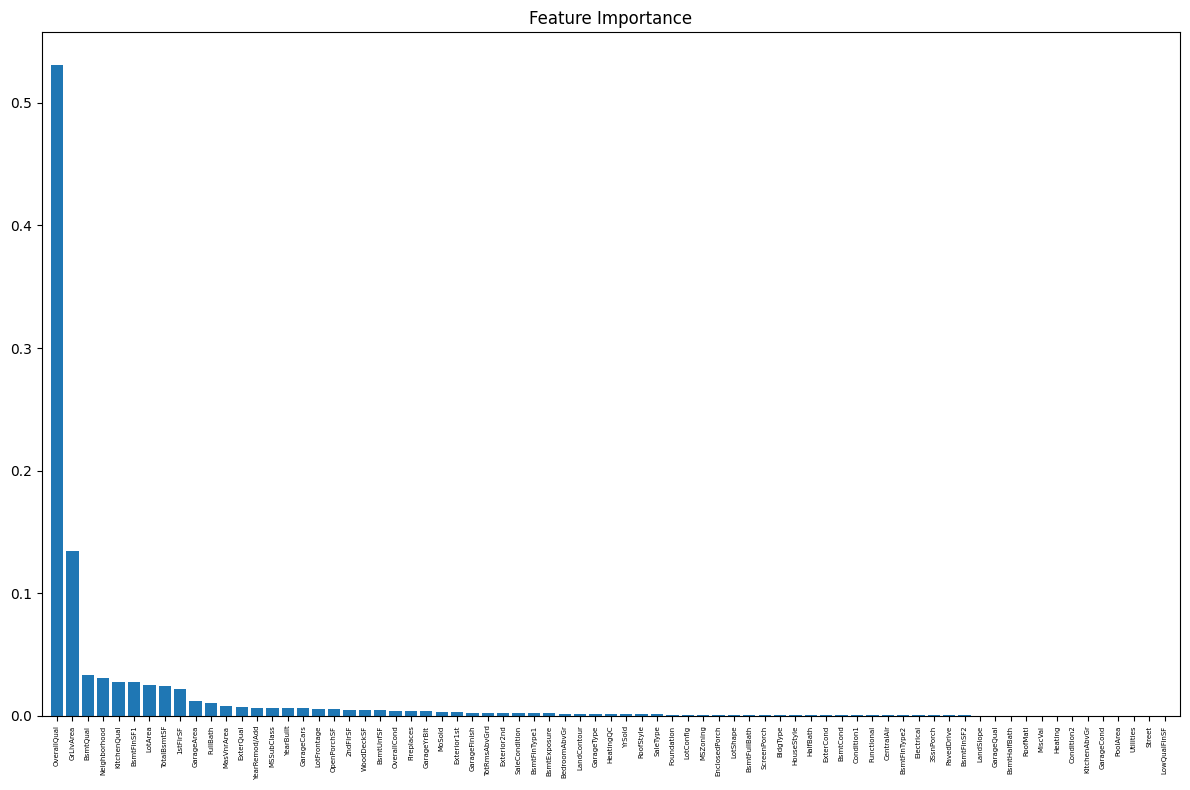

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500,
                           criterion='squared_error',
                           random_state=random_state)

rf.fit(X_train_enc, y_train)

feat_rank = rf.feature_importances_
indices = np.argsort(feat_rank)[::-1]
for f in range(X_train_enc.shape[1]):
    print('%2d) %s: %f' %(f+1, X_train_enc.columns[indices[f]], feat_rank[indices[f]]))

plt.figure(figsize=(12,8))
plt.title('Feature Importance')
plt.bar(range(X_train_enc.shape[1]), feat_rank[indices], align='center')
plt.xticks(range(X_train_enc.shape[1]), X_train_enc.columns[indices], rotation=90, size=5)
plt.xlim([-1, X_train_enc.shape[1]])
plt.tight_layout()
plt.show()

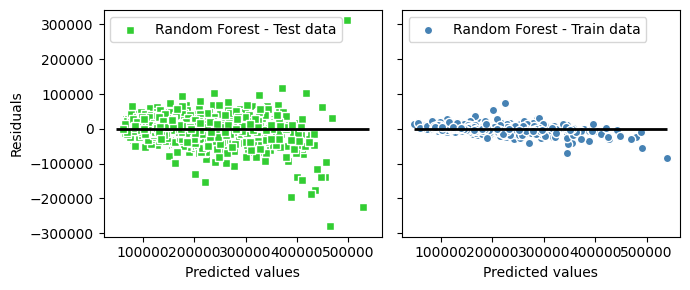

Train R2 score: 0.9818055550709968
Test R2 score: 0.8828352834001274


In [19]:
from sklearn.metrics import r2_score

def residual_plot(y_train,y_train_pred,
                  y_test, y_test_pred, title):
    x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
    x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True,)

    ax1.scatter(
        y_test_pred, y_test_pred - y_test,
        c='limegreen', marker='s',
        edgecolor='white', label=f'{title} - Test data')
    ax2.scatter(
        y_train_pred, y_train_pred - y_train,
        c='steelblue', marker='o',
        edgecolor='white', label=f'{title} - Train data')
    
    ax1.set_ylabel('Residuals')

    for ax in (ax1, ax2):
        ax.set_xlabel('Predicted values')
        ax.legend(loc='upper left')
        ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
                  color='black', lw=2)
    
    plt.tight_layout()
    plt.show()

y_train_pred = rf.predict(X_train_enc)
X_test_enc = tgt_encoder.transform(X_test)
y_test_pred = rf.predict(X_test_enc)
residual_plot(y_train, y_train_pred, y_test, y_test_pred, 'Random Forest')
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'Train R2 score: {r2_train}')
print(f'Test R2 score: {r2_test}')

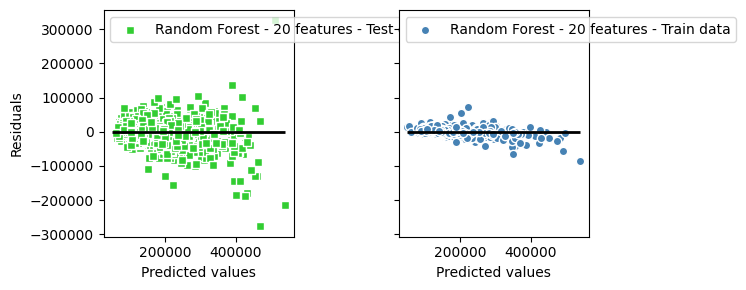

Train R2 score: 0.9811849545084639
Test R2 score: 0.8808674936040203


In [20]:
most_relevant_20 = X_train_enc.columns[indices[:20]]
X_train_20 = X_train_enc[most_relevant_20]
rf.fit(X_train_20, y_train)
y_train_pred = rf.predict(X_train_20)
y_test_pred = rf.predict(X_test_enc[most_relevant_20])
residual_plot(y_train, y_train_pred, y_test, y_test_pred, 'Random Forest - 20 features')
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'Train R2 score: {r2_train}')
print(f'Test R2 score: {r2_test}')

## Pearson and Spearman correlation
Now, to further decrease the number of features, we will check the correlation map to check for features highly correlated between each other or features with low correlation with the target `SalePrice`.

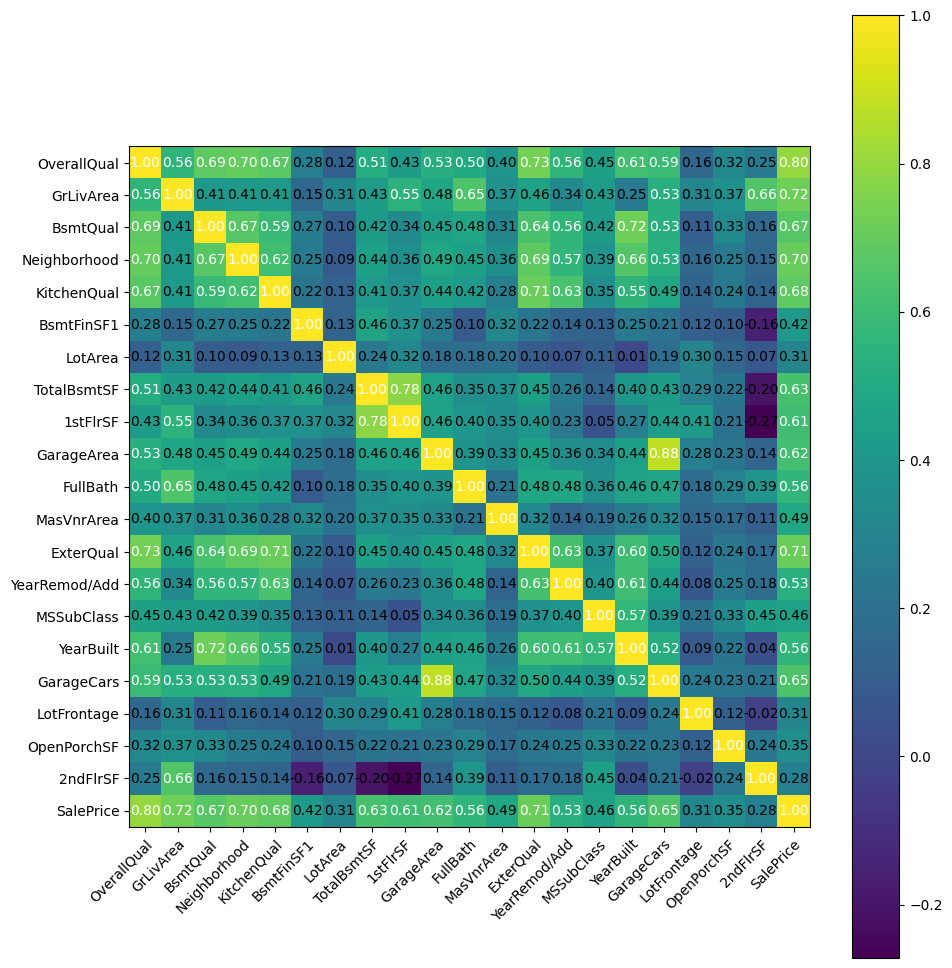

In [21]:
from mlxtend.plotting import heatmap

df_20 = X_train_20.copy()
df_20['SalePrice'] = y_train
pears_corr_mat = np.corrcoef(df_20.to_numpy().T)
heatmap(pears_corr_mat, row_names=df_20.columns, column_names=df_20.columns, figsize=(10,10))
plt.tight_layout()
plt.show()

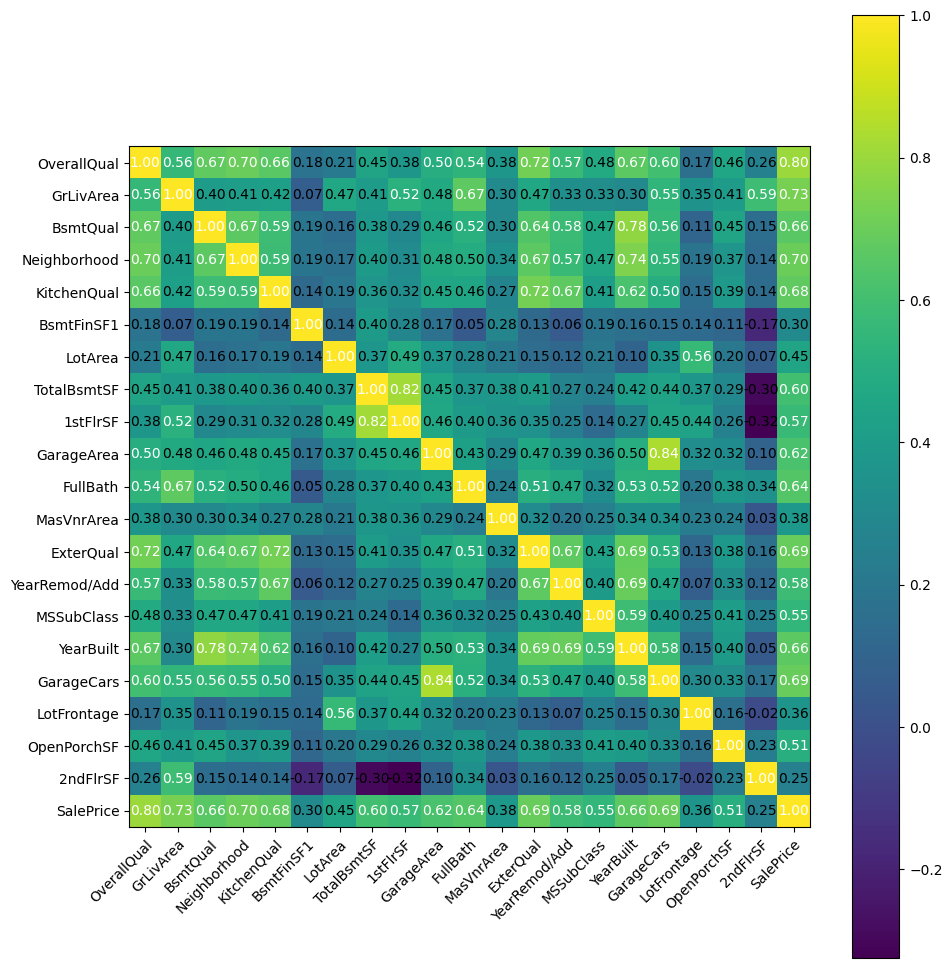

In [22]:
spearman_corr_mat = df_20.corr(method='spearman').to_numpy()
heatmap(spearman_corr_mat, row_names=df_20.columns, column_names=df_20.columns, figsize=(10,10))
plt.tight_layout()
plt.show()

Spearman correlations shows more or less the same values of the Pearson correlation
The following can be observed
- `2ndFlrSF`, `OpenPorchSF`, `LotFrontage` and `LotArea` have all low correlation with the target `SalePrice`.
  They also have low correlation with other features, except for `2ndFlrSF` which have a moderately strong 
  correlation with `GrLivArea` (they carry some grade of redundant information).
- `GarageCars` and `GarageArea` are highly correlated between each other as they carry a large quantity of redundant
information

We can try to remove these features and keep only one between `GarageCars` and `GarageArea`.

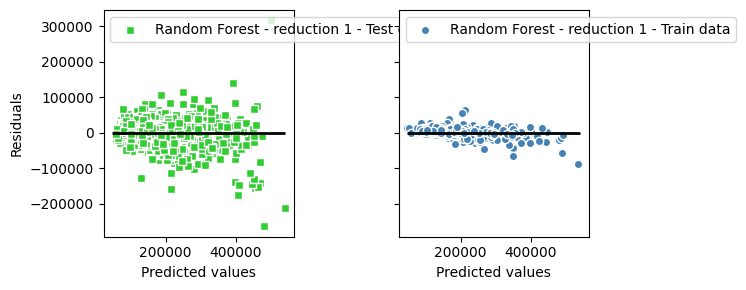

Train R2 score: 0.9809664061906133
Test R2 score: 0.8835895362864062


In [23]:
red1 = ['2ndFlrSF', 'OpenPorchSF', 'LotFrontage', 'LotArea', 'GarageCars']
X_train_red1 = X_train_20.drop(columns=red1)
X_test_red1 = X_test_enc[most_relevant_20].drop(columns=red1)
rf.fit(X_train_red1, y_train)
y_train_pred = rf.predict(X_train_red1)
y_test_pred = rf.predict(X_test_red1)
residual_plot(y_train, y_train_pred, y_test, y_test_pred, 'Random Forest - reduction 1')
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'Train R2 score: {r2_train}')
print(f'Test R2 score: {r2_test}')

We are still overfitting on the training set but the removal of the features did not bring any performance penalties so we can exclude them.
## Mutual Information scores
Now we will use mutual information to detect non-linear relationship between the features and the target vai

In [24]:
X_train_red1.info()

<class 'pandas.DataFrame'>
Index: 693 entries, 787 to 872
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OverallQual    693 non-null    int8   
 1   GrLivArea      693 non-null    float64
 2   BsmtQual       693 non-null    int8   
 3   Neighborhood   693 non-null    float64
 4   KitchenQual    693 non-null    int8   
 5   BsmtFinSF1     693 non-null    float64
 6   TotalBsmtSF    693 non-null    float64
 7   1stFlrSF       693 non-null    float64
 8   GarageArea     693 non-null    float64
 9   FullBath       693 non-null    int64  
 10  MasVnrArea     693 non-null    float64
 11  ExterQual      693 non-null    int8   
 12  YearRemod/Add  693 non-null    int64  
 13  MSSubClass     693 non-null    float64
 14  YearBuilt      693 non-null    int64  
dtypes: float64(8), int64(3), int8(4)
memory usage: 67.7 KB


In [25]:
discrete_feat = X_train_red1.select_dtypes(include=['int64', 'int8']).columns
discrete_mask = X_train_red1.columns.isin(discrete_feat)
discrete_mask

array([ True, False,  True, False,  True, False, False, False, False,
        True, False,  True,  True, False,  True])

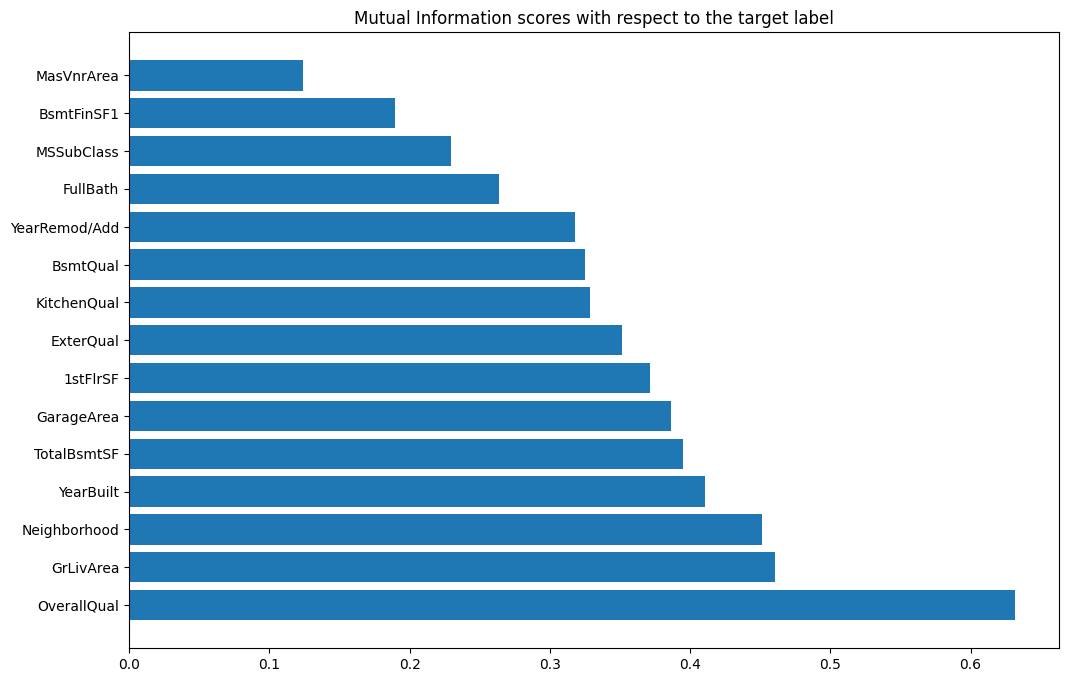

In [26]:
# Calculate and plot MI Scores
from sklearn.feature_selection import mutual_info_regression

discrete_feat = X_train_red1.select_dtypes(include=['int64', 'int8']).columns
discrete_mask = X_train_red1.columns.isin(discrete_feat)

def get_mi_scores(X, y, discrete_mask):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_mask)
    mi_scores = pd.Series(mi_scores, name='MI Scores' ,index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(mi_scores):
    plt.figure(figsize=(12,8))
    plt.barh(mi_scores.index, mi_scores.values)
    plt.title('Mutual Information scores with respect to the target label')
    plt.show()

mi_scores = get_mi_scores(X_train_red1, y_train, discrete_mask)
plot_mi_scores(mi_scores)

MI scores confirm that `GrLivArea` and `OverallQual` are the best predictors, while the other features ranking differs slightly with respect to the Random Forest one.

# PCA
In this section we will try to combine the features to obtain a more compact and informative set derived from them. In this case we will use Principal Component Analysis to project the features along the axes with the most variance.

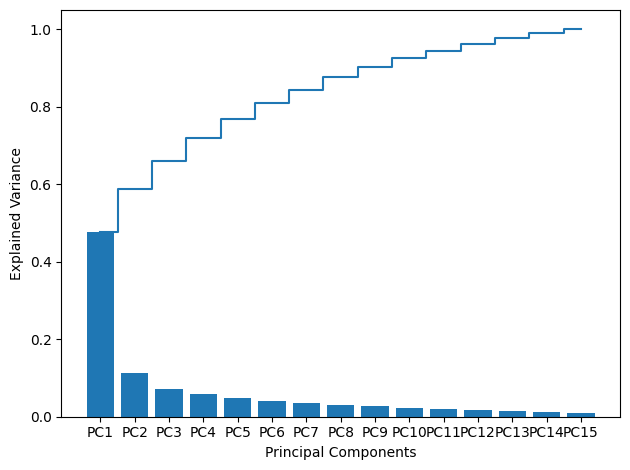

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize datasets before PCA decomposition
sc = StandardScaler()
X_train_red1_std = sc.fit_transform(X_train_red1)
X_test_red1_std = sc.transform(X_test_red1)

pca = PCA(n_components=None)
pca.fit(X_train_red1_std)
exp_var_ratio = pca.explained_variance_ratio_

feat_num = X_train_red1_std.shape[1]
plt.bar(range(feat_num), exp_var_ratio, align='center', label='Explained Variance ratio', )
plt.step(range(feat_num), np.cumsum(exp_var_ratio), where='mid', label='Cumulative Explained Variance ratio')
plt.xticks(range(feat_num), labels=[f'PC{i+1}' for i in range(feat_num)])
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')
plt.tight_layout()
plt.show()

Let's try to only keep the 7 principal components with most variance

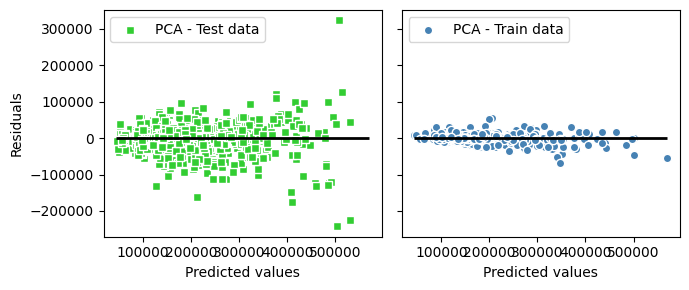

Train R2 score: 0.981587457482704
Test R2 score: 0.8771865513395813


In [ ]:
pca_7comp = PCA(n_components=7)

# Transform datasets
X_train_pca = pca_7comp.fit_transform(X_train_red1_std)
X_test_pca = pca_7comp.transform(X_test_red1_std)

rf.fit(X_train_pca, y_train)
y_train_pred = rf.predict(X_train_pca)
y_test_pred = rf.predict(X_test_pca)

residual_plot(y_train, y_train_pred, y_test, y_test_pred, 'PCA')
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'Train R2 score: {r2_train}')
print(f'Test R2 score: {r2_test}')

The performances decreased a little bit on the test set, but we removed 8 features from the dataset.